# Parathyroid gland model: example simulations

All model parameters are fixed in `ptg_model/parameters.py`. Each simulation only prescribes the plasma levels of calcium, phosphate and calcitriol and starts from the corresponding steady state. Time is in hours.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from ptg_model.model import deriv
from ptg_model.steady_state import steady_state
from ptg_model.parameters import C_OPT, P_OPT, D_OPT
from ptg_model.utils import smooth_pw


def simulate(calcium, phosphate, calcitriol, pth, t_end, t_eval, gfr=1.0):
    y0 = steady_state(calcium(0), phosphate(0), calcitriol(0), pth, gfr)
    s0 = y0[0] + y0[1]
    return solve_ivp(deriv, (0, t_end), y0, args=(s0, calcium, phosphate, calcitriol, gfr),
                     method="BDF", t_eval=t_eval, rtol=1e-8, atol=1e-10)

## Hysteresis

Following the protocol of Schwarz et al. (1998), cycles of induced hypocalcemia are separated by a brief return to normocalcemia. Experimentally, the first hypocalcemic episode produced a strong PTH peak from stored hormone, but no second transient peak, as the short recovery was insufficient to replenish storage. The simulation reproduces this hysteresis.

PTH peak 6.24 x baseline


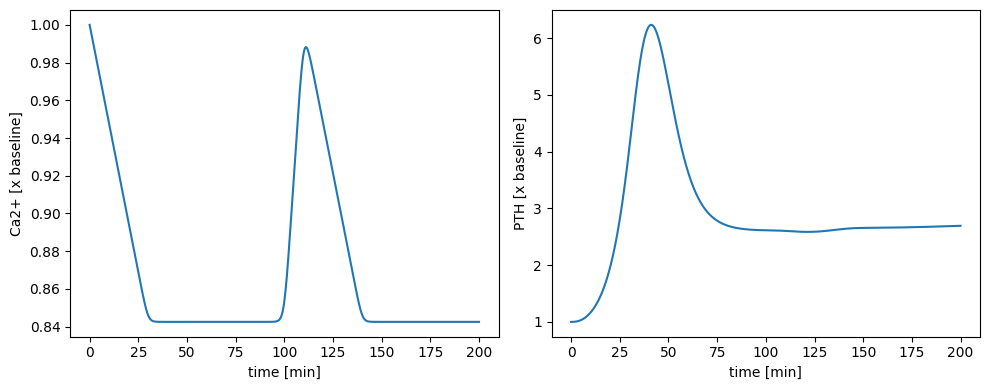

In [2]:
def calcium_cycles(cycles=3, drop=0.85):
    c_high, c_low = C_OPT, drop * C_OPT
    t_drop, t_hold, t_rise = 30 / 60, 70 / 60, 10 / 60
    tau_drop, tau_rise = 10 / 60, 3 / 60
    c_min = c_high - (c_high - c_low) / (1 - np.exp(-0.5 / tau_drop)) * (1 - np.exp(-1 / tau_drop))
    c_back = c_min + (c_high - c_min) * (np.exp(t_rise / tau_rise) - 1) / (np.exp((1 / 6) / tau_rise) - 1)
    period = t_drop + t_hold + t_rise
    x, y = [0.0], [c_high]
    for k in range(cycles):
        x += [k * period + t_drop, k * period + t_drop + t_hold, (k + 1) * period]
        y += [c_min, c_min, c_back]
    return np.array([x, y])


endpoints = calcium_cycles()
calcium = lambda t: smooth_pw(t, endpoints, alpha=60)
t_end = 200 / 60
t = np.linspace(0, t_end, 1000)
sol = simulate(calcium, lambda t: P_OPT, lambda t: D_OPT, 40.0, t_end, t)

ca = calcium(t)
pth = sol.y[3]
print(f"PTH peak {pth.max() / pth[0]:.2f} x baseline")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(t * 60, ca / ca[0])
ax[0].set_ylabel("Ca2+ [x baseline]")
ax[1].plot(t * 60, pth / pth[0])
ax[1].set_ylabel("PTH [x baseline]")
for a in ax:
    a.set_xlabel("time [min]")
plt.tight_layout()
plt.show()

## Acute response to a fall in calcium

Calcium falls by 10 % either exponentially within minutes or linearly over two hours.

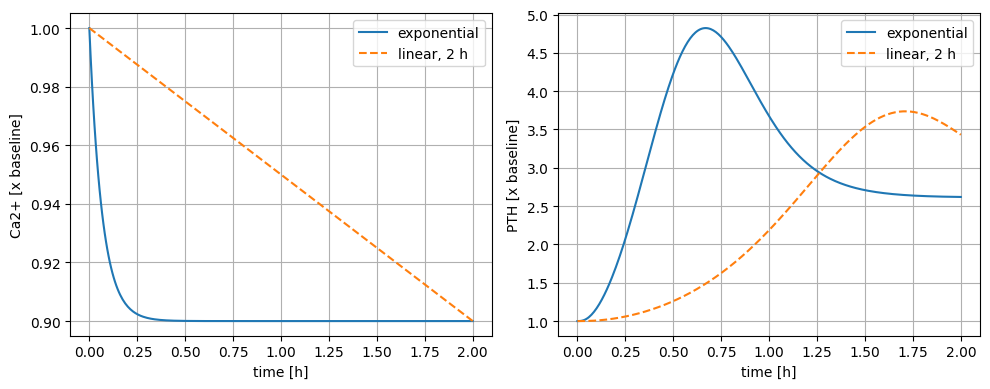

In [3]:
c_low = 0.9 * C_OPT
profiles = {
    "exponential": lambda t: c_low + (C_OPT - c_low) * np.exp(-t / (0.2 / 3)),
    "linear, 2 h": lambda t: C_OPT + (c_low - C_OPT) * min(t, 2.0) / 2.0,
}
t_end = 2.0
t = np.linspace(0, t_end, 300)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for (label, calcium), ls in zip(profiles.items(), ["-", "--"]):
    sol = simulate(calcium, lambda t: P_OPT, lambda t: D_OPT, 36.9, t_end, t)
    ax[0].plot(t, [calcium(ti) / C_OPT for ti in t], ls, label=label)
    ax[1].plot(t, sol.y[3] / sol.y[3, 0], ls, label=label)
ax[0].set_ylabel("Ca2+ [x baseline]")
ax[1].set_ylabel("PTH [x baseline]")
for a in ax:
    a.set_xlabel("time [h]")
    a.grid(True)
    a.legend()
plt.tight_layout()
plt.show()

## Chronic changes in phosphate and calcitriol

After three months, phosphate rises by 20 % and calcitriol falls by 50 %, as in progressive chronic kidney disease. Calcium is held at its reference level. The sustained stimulus drives gland hyperplasia and a slow rise in PTH over two years.

after 2 years: PTH 3.26 x, cell mass 1.02 x


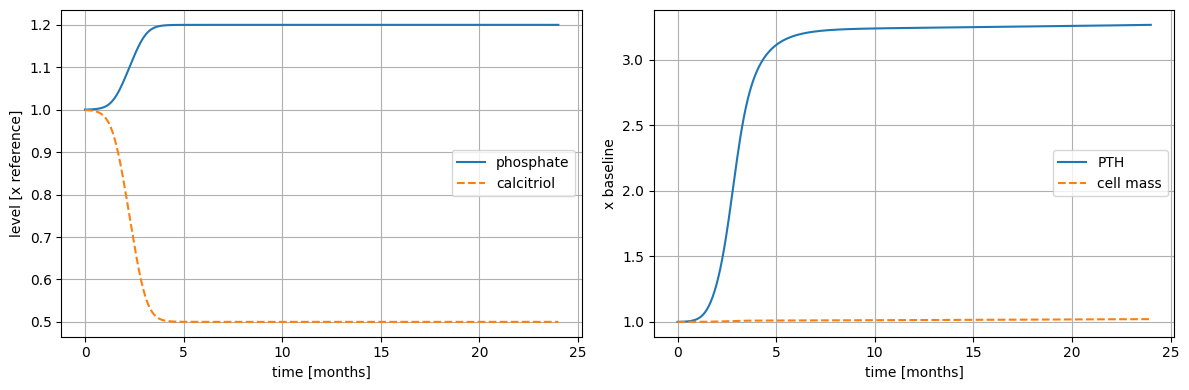

In [4]:
t_end = 24 * 30 * 24
t_step = 24 * 30 * 3


def step(factor):
    return np.array([[0.0, t_step / 2, t_step, t_end], [1.0, 1.0, factor, factor]]) / [[t_end], [1]]


phosphate = lambda t: P_OPT * smooth_pw(t / t_end, step(1.2))
calcitriol = lambda t: D_OPT * smooth_pw(t / t_end, step(0.5))
t = np.linspace(0, t_end, 500)
sol = simulate(lambda t: C_OPT, phosphate, calcitriol, 31.7, t_end, t)

pth = sol.y[3]
mass = sol.y[0] + sol.y[1]
print(f"after 2 years: PTH {pth[-1] / pth[0]:.2f} x, cell mass {mass[-1] / mass[0]:.2f} x")

months = t / (24 * 30)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(months, phosphate(t) / P_OPT, label="phosphate")
ax[0].plot(months, calcitriol(t) / D_OPT, "--", label="calcitriol")
ax[0].set_ylabel("level [x reference]")
ax[1].plot(months, pth / pth[0], label="PTH")
ax[1].plot(months, mass / mass[0], "--", label="cell mass")
ax[1].set_ylabel("x baseline")
for a in ax:
    a.set_xlabel("time [months]")
    a.grid(True)
    a.legend()
plt.tight_layout()
plt.show()